<a href="https://colab.research.google.com/github/Nestor20193767/Grupo2---Proyecto/blob/main/Analisis_database_MIT_Arritmias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avance 2 – Dataset, Preprocesamiento y Pipeline de Datos
## Proyecto: Generación Sintética de Señales ECG con TCN-CVAE
### Base de Datos: MIT-BIH Arrhythmia Database

---
**Flujo del notebook:**
1. Instalación de dependencias
2. Carga del dataset desde Kaggle
3. Descripción detallada del dataset
4. Pipeline de preprocesamiento (filtrado, segmentación, normalización)
5. Visualización antes/después del preprocesamiento
6. Mapeo de etiquetas AAMI
7. División train/val/test (sin contaminación por paciente)
8. Manejo del desbalance de clases
9. Resumen final del pipeline

## 1. Instalación de Dependencias

In [1]:
# Instalación de todas las librerías necesarias
!pip install -q kagglehub[pandas-datasets] wfdb neurokit2 scipy polars imbalanced-learn
print("✅ Dependencias instaladas correctamente")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
✅ Dependencias instaladas correctamente


In [2]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import wfdb
import neurokit2 as nk
import kagglehub
from kagglehub import KaggleDatasetAdapter
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt, butter as butter_sos
from scipy.signal import butter as _butter
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
import os
import glob

warnings.filterwarnings('ignore')
np.random.seed(42)

# Estilo de gráficos
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.size'] = 11

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga del Dataset desde Kaggle

**Dataset:** MIT-BIH Arrhythmia Database  
**Fuente:** PhysioNet (Kaggle mirror)  
**Enlace:** https://www.kaggle.com/datasets/mondejar/mitbih-database  
**Justificación:** Es el benchmark gold-standard para clasificación y generación de arritmias. Contiene registros con anotaciones de expertos cardiólogos, frecuencia de muestreo de 360 Hz y la diversidad de clases necesaria para entrenar un modelo generativo condicional (CVAE).

In [8]:
# ─────────────────────────────────────────────────────────
#  DESCARGA DEL DATASET (Directamente de PhysioNet)
# ─────────────────────────────────────────────────────────
import wfdb
import os
import glob

# Creamos una carpeta local para guardar los datos
wfdb_dir = os.path.join(os.getcwd(), 'mitdb_data')
os.makedirs(wfdb_dir, exist_ok=True)

print("⏳ Descargando MIT-BIH directamente desde PhysioNet (puede tardar un momento)...")

# wfdb descarga la base de datos oficial ('mitdb') con los formatos correctos
wfdb.dl_database('mitdb', dl_dir=wfdb_dir)
print(f"✅ Dataset descargado exitosamente en: {wfdb_dir}")

# Buscar los archivos .dat que necesita tu código
dat_files = glob.glob(os.path.join(wfdb_dir, '*.dat'))
print(f"\n📁 Archivos .dat encontrados: {len(dat_files)}")

# Detectar los IDs de los pacientes
if dat_files:
    record_ids = sorted(set([os.path.basename(f).replace('.dat', '') for f in dat_files]))
    print(f"\n👥 Registros de pacientes disponibles ({len(record_ids)} total):")
    print(record_ids)
else:
    print("❌ ERROR: No se encontraron archivos .dat.")
    record_ids = []

⏳ Descargando MIT-BIH directamente desde PhysioNet (puede tardar un momento)...
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list f

## 3. Descripción Detallada del Dataset

In [9]:
# ─────────────────────────────────────────────────────────
#  EXPLORACIÓN DE UN REGISTRO REPRESENTATIVO
# ─────────────────────────────────────────────────────────

# Validación de seguridad (evita errores si se saltó la celda anterior)
if not record_ids:
    raise ValueError("La lista 'record_ids' está vacía. Ejecuta primero la celda de descarga.")

sample_record_id = record_ids[0]  # Tomamos el primer registro
record_path = os.path.join(wfdb_dir, sample_record_id)

# Leer el registro con WFDB
record   = wfdb.rdrecord(record_path)
ann      = wfdb.rdann(record_path, 'atr')

print("=" * 60)
print(f"  DESCRIPCIÓN DEL DATASET  MIT-BIH ARRHYTHMIA DATABASE")
print("=" * 60)
print(f"\n📋 INFORMACIÓN GENERAL")
print(f"  Nombre            : MIT-BIH Arrhythmia Database")
print(f"  Fuente            : PhysioNet (Descarga directa vía wfdb)") # Texto actualizado
print(f"  Número de pacientes: {len(record_ids)}")
print(f"  Canales ECG       : {record.n_sig} (MLII y V5)")
print(f"  Frecuencia muest. : {record.fs} Hz")
print(f"  Duración/registro : ~30 minutos")
print(f"  Resolución        : 11 bits, ganancia 200 ADC/mV")
print(f"  Formato archivos  : .dat (señal binaria), .hea (cabecera), .atr (anotaciones)")
print(f"  Tipo de dato      : Señal biomédica 1D (ECG)")
print(f"\n📊 DETALLE DEL REGISTRO '{sample_record_id}'")
print(f"  Muestras totales  : {record.sig_len:,}")
print(f"  Anotaciones       : {len(ann.sample)} latidos")
print(f"  Nombres de señal  : {record.sig_name}")
print(f"  Unidades          : {record.units}")

# Mostrar las primeras anotaciones
print(f"\n📌 Primeras 10 anotaciones del registro {sample_record_id}:")
ann_df = pd.DataFrame({'sample': ann.sample[:10], 'symbol': ann.symbol[:10]})
print(ann_df.to_string(index=False))

  DESCRIPCIÓN DEL DATASET  MIT-BIH ARRHYTHMIA DATABASE

📋 INFORMACIÓN GENERAL
  Nombre            : MIT-BIH Arrhythmia Database
  Fuente            : PhysioNet (Descarga directa vía wfdb)
  Número de pacientes: 48
  Canales ECG       : 2 (MLII y V5)
  Frecuencia muest. : 360 Hz
  Duración/registro : ~30 minutos
  Resolución        : 11 bits, ganancia 200 ADC/mV
  Formato archivos  : .dat (señal binaria), .hea (cabecera), .atr (anotaciones)
  Tipo de dato      : Señal biomédica 1D (ECG)

📊 DETALLE DEL REGISTRO '100'
  Muestras totales  : 650,000
  Anotaciones       : 2274 latidos
  Nombres de señal  : ['MLII', 'V5']
  Unidades          : ['mV', 'mV']

📌 Primeras 10 anotaciones del registro 100:
 sample symbol
     18      +
     77      N
    370      N
    662      N
    946      N
   1231      N
   1515      N
   1809      N
   2044      A
   2402      N


In [10]:
# ─────────────────────────────────────────────────────────
#  CONTEO GLOBAL DE LATIDOS EN TODOS LOS REGISTROS
# ─────────────────────────────────────────────────────────

# Mapeo de etiquetas MIT-BIH → 5 clases AAMI
AAMI_MAP = {
    # N – Normal / latidos supraventriculares de escape
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # S – Supraventricular ectópico
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # V – Ventricular ectópico
    'V': 'V', 'E': 'V',
    # F – Fusión
    'F': 'F',
    # Q – Desconocido / artifacto
    '/': 'Q', 'f': 'Q', 'Q': 'Q', '?': 'Q'
}

global_counts_raw  = Counter()
global_counts_aami = Counter()
total_beats = 0

print("⏳ Contando latidos en todos los registros...")
for rid in record_ids:
    try:
        a = wfdb.rdann(os.path.join(wfdb_dir, rid), 'atr')
        for sym in a.symbol:
            global_counts_raw[sym] += 1
            if sym in AAMI_MAP:
                global_counts_aami[AAMI_MAP[sym]] += 1
                total_beats += 1
    except Exception:
        pass

print(f"\n✅ Latidos totales (válidos AAMI): {total_beats:,}")
print(f"\n📊 DISTRIBUCIÓN POR CLASE AAMI:")
print(f"{'Clase':<8} {'Descripción':<28} {'Latidos':>8} {'%':>7}")
print("-" * 55)
class_desc = {'N': 'Normal', 'S': 'Supraventricular', 'V': 'Ventricular', 'F': 'Fusión', 'Q': 'Desconocido'}
for cls in ['N', 'S', 'V', 'F', 'Q']:
    cnt  = global_counts_aami[cls]
    pct  = cnt / total_beats * 100
    print(f"  {cls:<6} {class_desc[cls]:<28} {cnt:>8,} {pct:>6.1f}%")
print("-" * 55)
print(f"  {'TOTAL':<34} {total_beats:>8,} {'100.0%':>7}")

⏳ Contando latidos en todos los registros...

✅ Latidos totales (válidos AAMI): 109,494

📊 DISTRIBUCIÓN POR CLASE AAMI:
Clase    Descripción                   Latidos       %
-------------------------------------------------------
  N      Normal                         90,631   82.8%
  S      Supraventricular                2,781    2.5%
  V      Ventricular                     7,236    6.6%
  F      Fusión                            803    0.7%
  Q      Desconocido                     8,043    7.3%
-------------------------------------------------------
  TOTAL                               109,494  100.0%


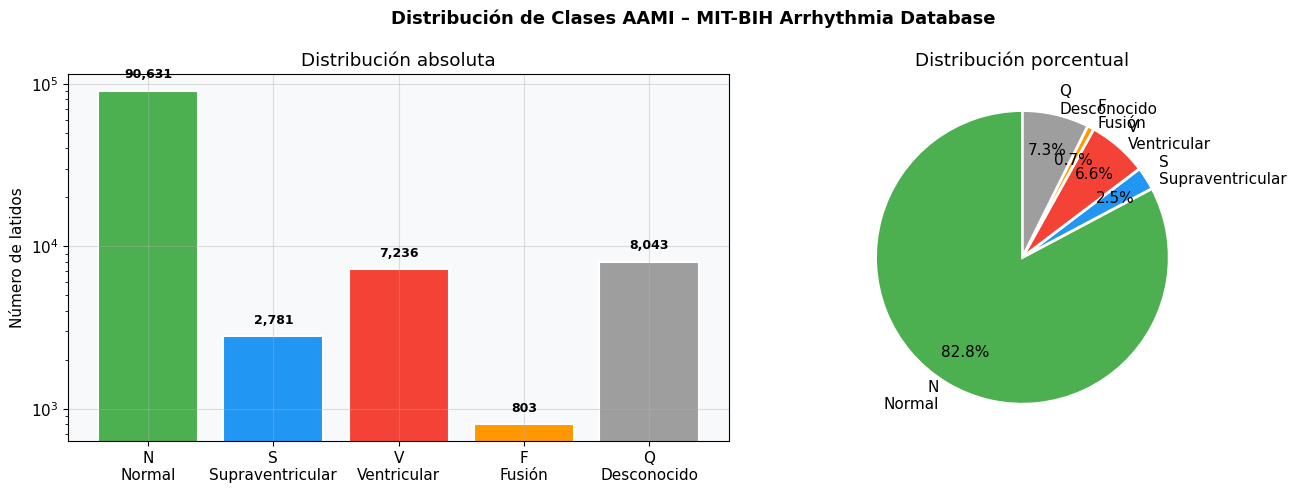

⚠️  DESBALANCE SEVERO: La clase N domina (~90%). Se requiere estrategia de balanceo.


In [11]:
# ─────────────────────────────────────────────────────────
#  VISUALIZACIÓN DE LA DISTRIBUCIÓN DE CLASES
# ─────────────────────────────────────────────────────────
classes  = ['N', 'S', 'V', 'F', 'Q']
counts   = [global_counts_aami[c] for c in classes]
labels   = [f"{c}\n{class_desc[c]}" for c in classes]
colors   = ['#4CAF50', '#2196F3', '#F44336', '#FF9800', '#9E9E9E']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases AAMI – MIT-BIH Arrhythmia Database', fontsize=13, fontweight='bold')

# Barras
bars = ax1.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Número de latidos')
ax1.set_title('Distribución absoluta')
ax1.set_yscale('log')  # Escala log para visualizar mejor el desbalance
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
             f'{cnt:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pastel
wedges, texts, autotexts = ax2.pie(counts, labels=labels, colors=colors,
                                    autopct='%1.1f%%', startangle=90,
                                    pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Distribución porcentual')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("⚠️  DESBALANCE SEVERO: La clase N domina (~90%). Se requiere estrategia de balanceo.")

## 4. Pipeline de Preprocesamiento
### Paso 4.1 – Filtrado de la señal ECG cruda

In [12]:
# ─────────────────────────────────────────────────────────
#  FUNCIONES DE FILTRADO  (Procesamiento de Señales)
# ─────────────────────────────────────────────────────────
FS = 360  # Frecuencia de muestreo MIT-BIH

def highpass_filter(signal, cutoff=0.5, fs=FS, order=4):
    """Elimina la deriva de la línea base (wandering baseline)."""
    nyq = fs / 2.0
    b, a = butter(order, cutoff / nyq, btype='high')
    return filtfilt(b, a, signal)

def notch_filter(signal, freq=60.0, fs=FS, quality=30):
    """Elimina el ruido de la red eléctrica (60 Hz para MIT-BIH)."""
    b, a = iirnotch(freq, quality, fs)
    return filtfilt(b, a, signal)

def lowpass_filter(signal, cutoff=45.0, fs=FS, order=4):
    """Elimina ruido muscular (EMG) conservando el pico R."""
    nyq = fs / 2.0
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, signal)

def full_ecg_pipeline(raw_signal, fs=FS):
    """Pipeline completo: highpass → notch → lowpass."""
    step1 = highpass_filter(raw_signal, cutoff=0.5, fs=fs)
    step2 = notch_filter(step1, freq=60.0, fs=fs)
    step3 = lowpass_filter(step2, cutoff=45.0, fs=fs)
    return step3

print("✅ Funciones de filtrado definidas:")
print("  → highpass_filter  : Butterworth 4° orden, corte 0.5 Hz (elimina baseline wander)")
print("  → notch_filter     : IIR Notch, 60 Hz, Q=30 (elimina ruido red eléctrica)")
print("  → lowpass_filter   : Butterworth 4° orden, corte 45 Hz (elimina EMG muscular)")
print("  → full_ecg_pipeline: Encadena los 3 filtros en secuencia")

✅ Funciones de filtrado definidas:
  → highpass_filter  : Butterworth 4° orden, corte 0.5 Hz (elimina baseline wander)
  → notch_filter     : IIR Notch, 60 Hz, Q=30 (elimina ruido red eléctrica)
  → lowpass_filter   : Butterworth 4° orden, corte 45 Hz (elimina EMG muscular)
  → full_ecg_pipeline: Encadena los 3 filtros en secuencia


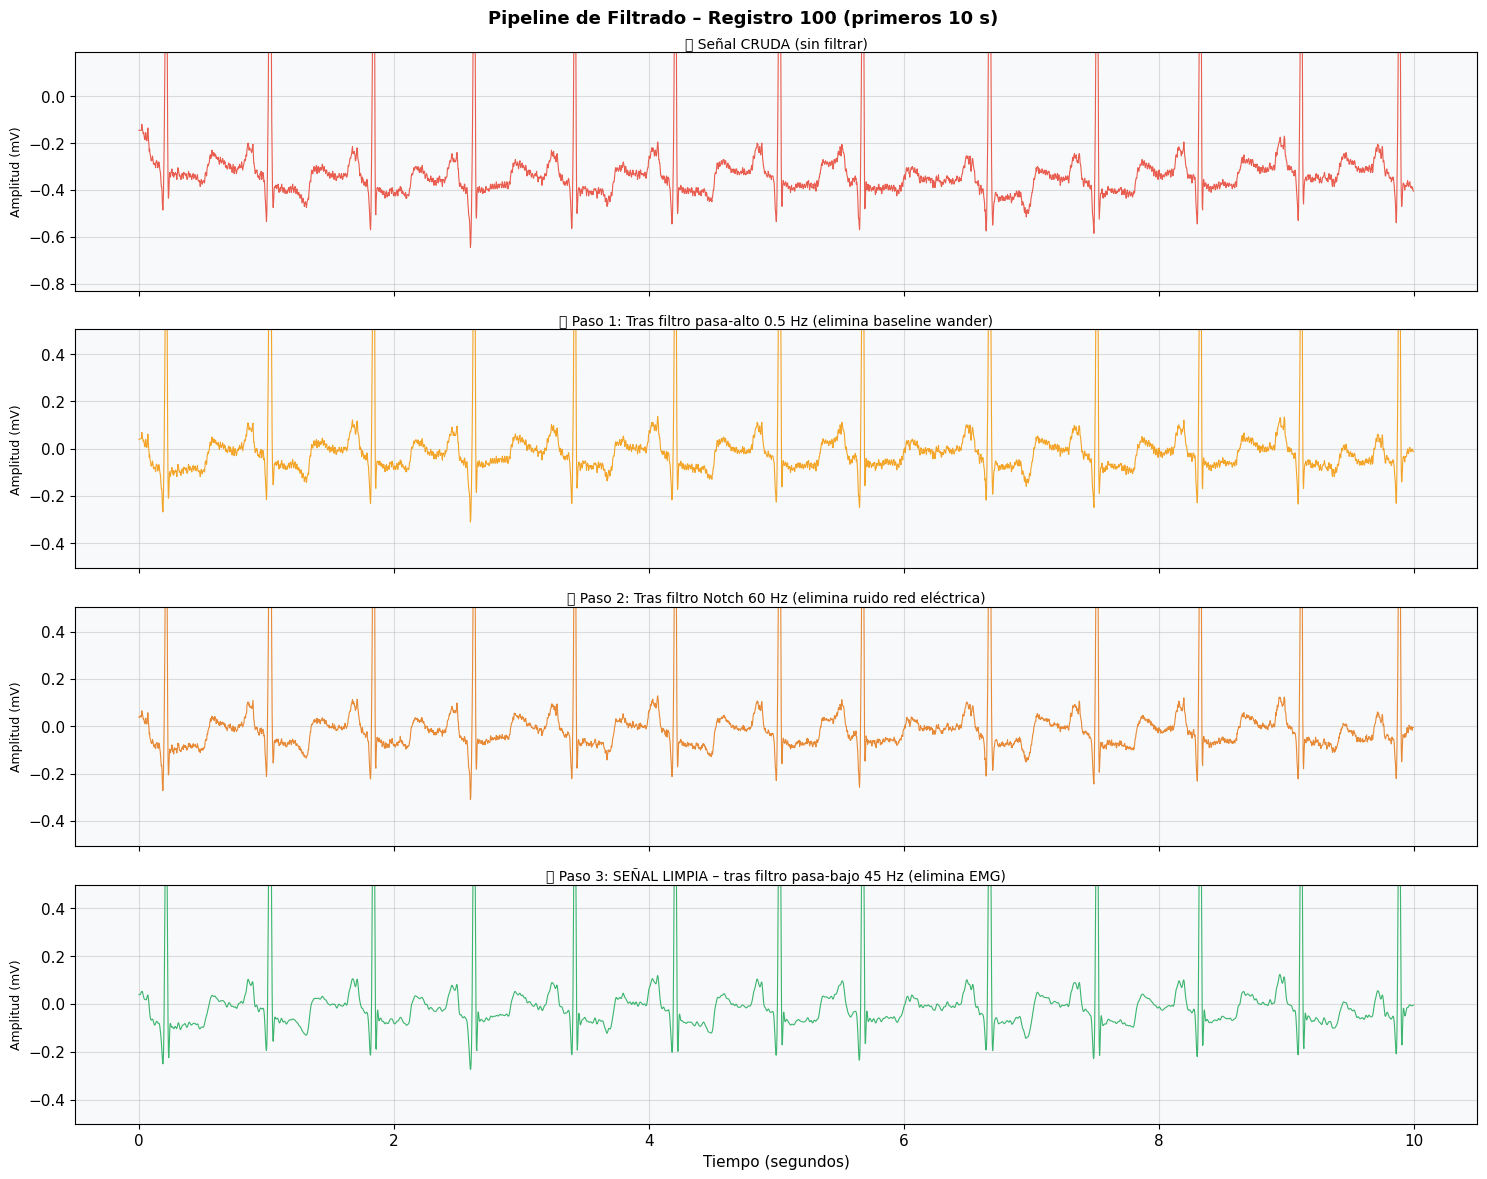

✅ Filtrado completo. La señal verde es la que se usará para segmentación.


In [13]:
# ─────────────────────────────────────────────────────────
#  VISUALIZACIÓN ANTES Y DESPUÉS DEL FILTRADO
# ─────────────────────────────────────────────────────────
# Cargamos 10 segundos del primer registro
record_sample = wfdb.rdrecord(os.path.join(wfdb_dir, record_ids[0]), sampto=10*FS)
raw_ecg = record_sample.p_signal[:, 0].copy()  # Canal MLII

# Aplicar pipeline paso a paso para visualizar cada etapa
ecg_hp  = highpass_filter(raw_ecg)
ecg_hp_notch = notch_filter(ecg_hp)
ecg_clean = lowpass_filter(ecg_hp_notch)

time_axis = np.arange(len(raw_ecg)) / FS

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
fig.suptitle(f'Pipeline de Filtrado – Registro {record_ids[0]} (primeros 10 s)',
             fontsize=13, fontweight='bold')

signals  = [raw_ecg,  ecg_hp,  ecg_hp_notch, ecg_clean]
titles   = ['🔴 Señal CRUDA (sin filtrar)',
             '🟡 Paso 1: Tras filtro pasa-alto 0.5 Hz (elimina baseline wander)',
             '🟠 Paso 2: Tras filtro Notch 60 Hz (elimina ruido red eléctrica)',
             '🟢 Paso 3: SEÑAL LIMPIA – tras filtro pasa-bajo 45 Hz (elimina EMG)']
colors_sig = ['#e74c3c', '#f39c12', '#e67e22', '#27ae60']

for ax, sig, title, col in zip(axes, signals, titles, colors_sig):
    ax.plot(time_axis, sig, color=col, linewidth=0.8, alpha=0.9)
    ax.set_ylabel('Amplitud (mV)', fontsize=9)
    ax.set_title(title, fontsize=10, pad=3)
    ax.set_ylim([sig.mean() - 3*sig.std(), sig.mean() + 3*sig.std()])

axes[-1].set_xlabel('Tiempo (segundos)')
plt.tight_layout()
plt.savefig('filtrado_ecg.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Filtrado completo. La señal verde es la que se usará para segmentación.")

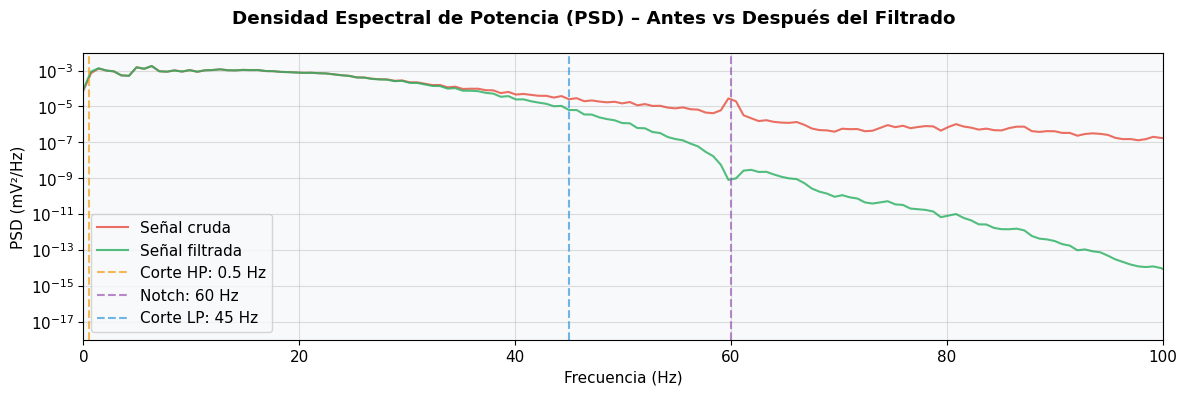

✅ PSD confirma: ruido de red eléctrica (60 Hz) y artefactos de alta frecuencia eliminados.


In [14]:
# ─────────────────────────────────────────────────────────
#  ANÁLISIS DE DENSIDAD ESPECTRAL (PSD)
#  Para verificar que los filtros operaron correctamente
# ─────────────────────────────────────────────────────────
from scipy.signal import welch

fig, ax = plt.subplots(figsize=(12, 4))
fig.suptitle('Densidad Espectral de Potencia (PSD) – Antes vs Después del Filtrado', fontweight='bold')

freqs_raw,   psd_raw   = welch(raw_ecg,   fs=FS, nperseg=512)
freqs_clean, psd_clean = welch(ecg_clean, fs=FS, nperseg=512)

ax.semilogy(freqs_raw,   psd_raw,   color='#e74c3c', linewidth=1.5, alpha=0.8, label='Señal cruda')
ax.semilogy(freqs_clean, psd_clean, color='#27ae60', linewidth=1.5, alpha=0.8, label='Señal filtrada')

# Marcar las frecuencias de corte
ax.axvline(0.5,  color='#f39c12', linestyle='--', alpha=0.7, label='Corte HP: 0.5 Hz')
ax.axvline(60,   color='#9b59b6', linestyle='--', alpha=0.7, label='Notch: 60 Hz')
ax.axvline(45,   color='#3498db', linestyle='--', alpha=0.7, label='Corte LP: 45 Hz')

ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('PSD (mV²/Hz)')
ax.legend()
ax.set_xlim([0, 100])
plt.tight_layout()
plt.savefig('psd_analisis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PSD confirma: ruido de red eléctrica (60 Hz) y artefactos de alta frecuencia eliminados.")

### Paso 4.2 – Detección de Picos R y Segmentación

In [15]:
# ─────────────────────────────────────────────────────────
#  SEGMENTACIÓN DE LATIDOS
#  Usamos las anotaciones MIT-BIH (precisas) como posiciones R
# ─────────────────────────────────────────────────────────

WINDOW_SIZE  = 256    # Longitud fija del latido (potencia de 2)
HALF_WINDOW  = WINDOW_SIZE // 2  # 128 muestras antes y después del pico R

def segment_beats(record_id, wfdb_dir, aami_map, window=WINDOW_SIZE):
    """
    Extrae latidos segmentados de un registro MIT-BIH.

    Returns:
        beats  : np.ndarray de shape (N_beats, window)
        labels : list de etiquetas AAMI
        patient_ids: list con el ID del paciente
    """
    half = window // 2
    rpath = os.path.join(wfdb_dir, record_id)

    rec = wfdb.rdrecord(rpath)
    ann = wfdb.rdann(rpath, 'atr')

    # Señal cruda (canal MLII)
    raw = rec.p_signal[:, 0]

    # Señal filtrada
    clean = full_ecg_pipeline(raw, fs=rec.fs)

    beats, labels, pids = [], [], []

    for sample, sym in zip(ann.sample, ann.symbol):
        if sym not in aami_map:
            continue  # Ignorar anotaciones que no son latidos

        start = sample - half
        end   = sample + half

        # Verificar límites: descartar latidos en los bordes del registro
        if start < 0 or end > len(clean):
            continue

        beat = clean[start:end]

        # Normalización Min-Max individual (0 a 1)
        b_min, b_max = beat.min(), beat.max()
        if b_max - b_min < 1e-6:  # Evitar división por cero
            continue
        beat_norm = (beat - b_min) / (b_max - b_min)

        beats.append(beat_norm)
        labels.append(aami_map[sym])
        pids.append(record_id)

    return np.array(beats, dtype=np.float32), labels, pids

print("✅ Función de segmentación definida.")
print(f"   Ventana por latido : {WINDOW_SIZE} muestras = {WINDOW_SIZE/FS*1000:.1f} ms")
print(f"   Centro en pico R   : ±{HALF_WINDOW} muestras ({HALF_WINDOW/FS*1000:.1f} ms)")
print(f"   Normalización      : Min-Max [0, 1] individual por latido")

✅ Función de segmentación definida.
   Ventana por latido : 256 muestras = 711.1 ms
   Centro en pico R   : ±128 muestras (355.6 ms)
   Normalización      : Min-Max [0, 1] individual por latido


In [16]:
# ─────────────────────────────────────────────────────────
#  EXTRACCIÓN DE TODOS LOS LATIDOS (todos los registros)
# ─────────────────────────────────────────────────────────
all_beats  = []
all_labels = []
all_pids   = []

print(f"⏳ Segmentando latidos de {len(record_ids)} registros...")
for i, rid in enumerate(record_ids):
    try:
        beats, labels, pids = segment_beats(rid, wfdb_dir, AAMI_MAP)
        all_beats.append(beats)
        all_labels.extend(labels)
        all_pids.extend(pids)
        print(f"  [{i+1:02d}/{len(record_ids)}] Registro {rid}: {len(labels):>5,} latidos extraídos")
    except Exception as e:
        print(f"  ⚠️  Error en registro {rid}: {e}")

# Concatenar todo
X = np.concatenate(all_beats, axis=0)    # Shape: (N_total, 256)
y = np.array(all_labels)                 # Shape: (N_total,)
patients = np.array(all_pids)            # Shape: (N_total,)

print(f"\n✅ Segmentación completa.")
print(f"   X shape  : {X.shape}  → ({X.shape[0]:,} latidos × {X.shape[1]} muestras)")
print(f"   y shape  : {y.shape}")
print(f"   dtype    : {X.dtype}")
print(f"   Memoria  : {X.nbytes / 1e6:.1f} MB")

⏳ Segmentando latidos de 48 registros...
  [01/48] Registro 100: 2,271 latidos extraídos
  [02/48] Registro 101: 1,864 latidos extraídos
  [03/48] Registro 102: 2,187 latidos extraídos
  [04/48] Registro 103: 2,083 latidos extraídos
  [05/48] Registro 104: 2,227 latidos extraídos
  [06/48] Registro 105: 2,572 latidos extraídos
  [07/48] Registro 106: 2,027 latidos extraídos
  [08/48] Registro 107: 2,136 latidos extraídos
  [09/48] Registro 108: 1,762 latidos extraídos
  [10/48] Registro 109: 2,530 latidos extraídos
  [11/48] Registro 111: 2,124 latidos extraídos
  [12/48] Registro 112: 2,537 latidos extraídos
  [13/48] Registro 113: 1,794 latidos extraídos
  [14/48] Registro 114: 1,879 latidos extraídos
  [15/48] Registro 115: 1,952 latidos extraídos
  [16/48] Registro 116: 2,411 latidos extraídos
  [17/48] Registro 117: 1,534 latidos extraídos
  [18/48] Registro 118: 2,277 latidos extraídos
  [19/48] Registro 119: 1,987 latidos extraídos
  [20/48] Registro 121: 1,862 latidos extraídos

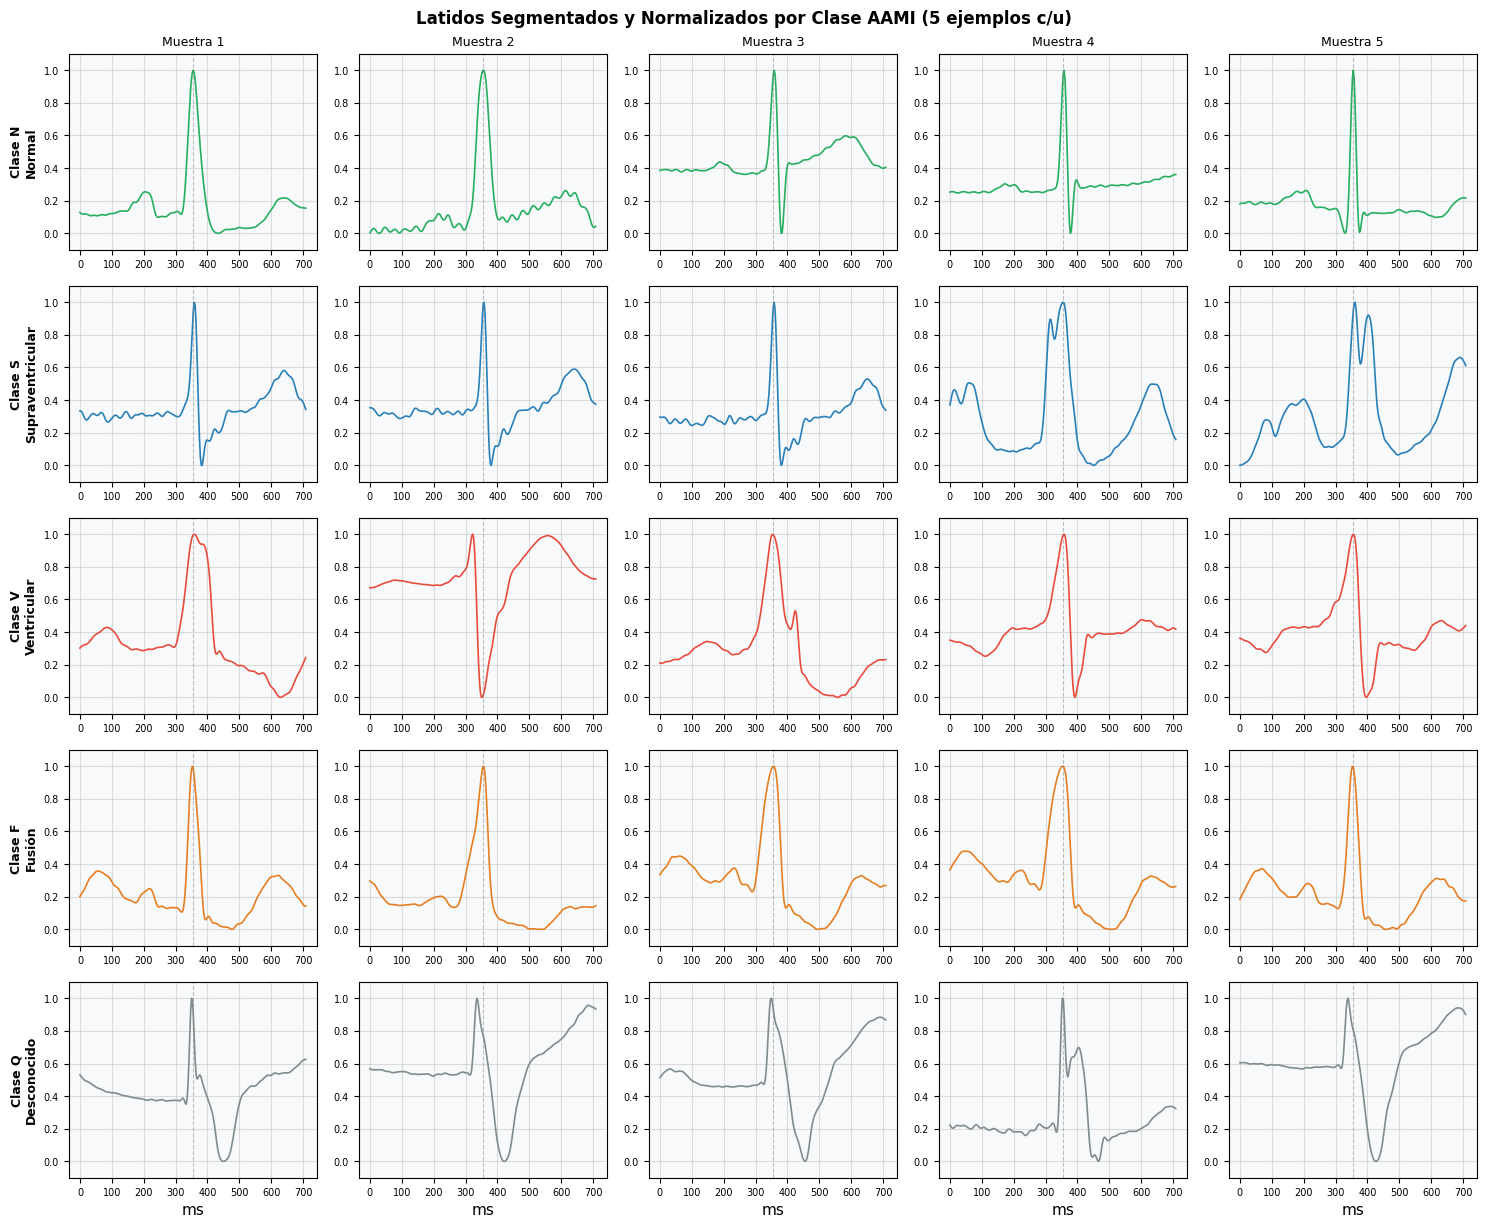

✅ Latidos centrados en el pico R y normalizados [0,1].


In [17]:
# ─────────────────────────────────────────────────────────
#  VISUALIZACIÓN DE LATIDOS SEGMENTADOS POR CLASE
# ─────────────────────────────────────────────────────────
classes_present = [c for c in ['N', 'S', 'V', 'F', 'Q'] if c in y]
colors_class = {'N': '#27ae60', 'S': '#2980b9', 'V': '#e74c3c', 'F': '#e67e22', 'Q': '#7f8c8d'}
n_samples_per_class = 5

fig, axes = plt.subplots(len(classes_present), n_samples_per_class,
                          figsize=(15, 2.5 * len(classes_present)))
fig.suptitle('Latidos Segmentados y Normalizados por Clase AAMI (5 ejemplos c/u)',
             fontsize=12, fontweight='bold')

t = np.arange(WINDOW_SIZE) / FS * 1000  # tiempo en ms

for row, cls in enumerate(classes_present):
    idx = np.where(y == cls)[0]
    sample_idx = np.random.choice(idx, size=min(n_samples_per_class, len(idx)), replace=False)

    for col, sidx in enumerate(sample_idx):
        ax = axes[row, col] if len(classes_present) > 1 else axes[col]
        ax.plot(t, X[sidx], color=colors_class[cls], linewidth=1.2)
        ax.axvline(x=HALF_WINDOW/FS*1000, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
        ax.set_ylim([-0.1, 1.1])
        if col == 0:
            ax.set_ylabel(f'Clase {cls}\n{class_desc[cls]}', fontsize=9, fontweight='bold')
        if row == 0:
            ax.set_title(f'Muestra {col+1}', fontsize=9)
        if row == len(classes_present) - 1:
            ax.set_xlabel('ms')
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('latidos_segmentados.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Latidos centrados en el pico R y normalizados [0,1].")

## 5. Indexación con Polars y Mapeo AAMI

In [18]:
# ─────────────────────────────────────────────────────────
#  GESTIÓN DE METADATA CON POLARS
# ─────────────────────────────────────────────────────────
# Crear índice para cada latido (el array X se referencia por posición)
beat_ids = np.arange(len(y))

meta_df = pl.DataFrame({
    'beat_id'  : beat_ids.tolist(),
    'patient'  : all_pids,
    'aami_class': all_labels,
})

# Añadir one-hot encoding en el DataFrame
for cls in ['N', 'S', 'V', 'F', 'Q']:
    meta_df = meta_df.with_columns(
        pl.when(pl.col('aami_class') == cls).then(1).otherwise(0).alias(f'oh_{cls}')
    )

print("📊 DataFrame de metadata (Polars):")
print(meta_df.head(10))
print(f"\n📐 Shape: {meta_df.shape[0]:,} filas × {meta_df.shape[1]} columnas")
print(f"\n📈 Distribución por clase:")
print(meta_df.group_by('aami_class').len().sort('len', descending=True))

📊 DataFrame de metadata (Polars):
shape: (10, 8)
┌─────────┬─────────┬────────────┬──────┬──────┬──────┬──────┬──────┐
│ beat_id ┆ patient ┆ aami_class ┆ oh_N ┆ oh_S ┆ oh_V ┆ oh_F ┆ oh_Q │
│ ---     ┆ ---     ┆ ---        ┆ ---  ┆ ---  ┆ ---  ┆ ---  ┆ ---  │
│ i64     ┆ str     ┆ str        ┆ i32  ┆ i32  ┆ i32  ┆ i32  ┆ i32  │
╞═════════╪═════════╪════════════╪══════╪══════╪══════╪══════╪══════╡
│ 0       ┆ 100     ┆ N          ┆ 1    ┆ 0    ┆ 0    ┆ 0    ┆ 0    │
│ 1       ┆ 100     ┆ N          ┆ 1    ┆ 0    ┆ 0    ┆ 0    ┆ 0    │
│ 2       ┆ 100     ┆ N          ┆ 1    ┆ 0    ┆ 0    ┆ 0    ┆ 0    │
│ 3       ┆ 100     ┆ N          ┆ 1    ┆ 0    ┆ 0    ┆ 0    ┆ 0    │
│ 4       ┆ 100     ┆ N          ┆ 1    ┆ 0    ┆ 0    ┆ 0    ┆ 0    │
│ 5       ┆ 100     ┆ N          ┆ 1    ┆ 0    ┆ 0    ┆ 0    ┆ 0    │
│ 6       ┆ 100     ┆ S          ┆ 0    ┆ 1    ┆ 0    ┆ 0    ┆ 0    │
│ 7       ┆ 100     ┆ N          ┆ 1    ┆ 0    ┆ 0    ┆ 0    ┆ 0    │
│ 8       ┆ 100     ┆ N          ┆ 1    ┆

## 6. División Train / Validation / Test (sin contaminación)

In [19]:
# ─────────────────────────────────────────────────────────
#  SPLIT BASADO EN PACIENTES (Patient-Level Split)
#  CRITERIO ANTI-CONTAMINACIÓN: un paciente NUNCA aparece
#  a la vez en entrenamiento y en evaluación.
# ─────────────────────────────────────────────────────────

unique_patients = list(set(all_pids))
np.random.seed(42)
np.random.shuffle(unique_patients)

n_total = len(unique_patients)
n_train = int(0.70 * n_total)  # 70%
n_val   = int(0.15 * n_total)  # 15%
# n_test  = remaining          # 15%

train_patients = set(unique_patients[:n_train])
val_patients   = set(unique_patients[n_train:n_train + n_val])
test_patients  = set(unique_patients[n_train + n_val:])

print("📌 CRITERIO DE DIVISIÓN: Patient-Level Split")
print("   → Un mismo paciente NO puede aparecer en train Y en val/test simultáneamente.")
print("   → Esto previene el data leakage: el modelo no ve morfologías del paciente de prueba.")
print()

# Crear máscaras booleanas
patient_arr  = np.array(all_pids)
train_mask   = np.array([p in train_patients for p in patient_arr])
val_mask     = np.array([p in val_patients   for p in patient_arr])
test_mask    = np.array([p in test_patients  for p in patient_arr])

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"{'Conjunto':<12} {'Pacientes':>10} {'Latidos':>12} {'%':>7}")
print("-" * 45)
for name, patients, arr in [
    ('Train',      train_patients, X_train),
    ('Validation', val_patients,   X_val),
    ('Test',       test_patients,  X_test)
]:
    pct = len(arr) / len(X) * 100
    print(f"  {name:<10} {len(patients):>10}   {len(arr):>10,}   {pct:>6.1f}%")
print("-" * 45)
print(f"  {'TOTAL':<10} {n_total:>10}   {len(X):>10,}   {'100.0%':>7}")

# Verificación de no contaminación
assert len(train_patients & val_patients)  == 0, "❌ Contaminación train-val!"
assert len(train_patients & test_patients) == 0, "❌ Contaminación train-test!"
assert len(val_patients   & test_patients) == 0, "❌ Contaminación val-test!"
print("\n✅ Verificación de no-contaminación: PASSED (0 pacientes solapados)")

📌 CRITERIO DE DIVISIÓN: Patient-Level Split
   → Un mismo paciente NO puede aparecer en train Y en val/test simultáneamente.
   → Esto previene el data leakage: el modelo no ve morfologías del paciente de prueba.

Conjunto      Pacientes      Latidos       %
---------------------------------------------
  Train              33       75,709     69.2%
  Validation          7       16,743     15.3%
  Test                8       16,999     15.5%
---------------------------------------------
  TOTAL              48      109,451    100.0%

✅ Verificación de no-contaminación: PASSED (0 pacientes solapados)


In [20]:
# ─────────────────────────────────────────────────────────
#  DISTRIBUCIÓN DE CLASES EN CADA SPLIT
# ─────────────────────────────────────────────────────────
def class_distribution(labels, title):
    cnts = Counter(labels)
    total = sum(cnts.values())
    print(f"\n  {title}")
    for cls in ['N', 'S', 'V', 'F', 'Q']:
        c = cnts.get(cls, 0)
        print(f"    {cls}: {c:>7,}  ({c/total*100:.1f}%)")

print("📊 Distribución de clases por split:")
class_distribution(y_train, f"TRAIN  ({len(y_train):,} latidos)")
class_distribution(y_val,   f"VAL    ({len(y_val):,} latidos)")
class_distribution(y_test,  f"TEST   ({len(y_test):,} latidos)")

📊 Distribución de clases por split:

  TRAIN  (75,709 latidos)
    N:  62,389  (82.4%)
    S:   2,495  (3.3%)
    V:   4,801  (6.3%)
    F:      48  (0.1%)
    Q:   5,976  (7.9%)

  VAL    (16,743 latidos)
    N:  15,264  (91.2%)
    S:      46  (0.3%)
    V:   1,056  (6.3%)
    F:     377  (2.3%)
    Q:       0  (0.0%)

  TEST   (16,999 latidos)
    N:  12,940  (76.1%)
    S:     240  (1.4%)
    V:   1,378  (8.1%)
    F:     377  (2.2%)
    Q:   2,064  (12.1%)


## 7. Estrategia de Manejo del Desbalance de Clases

In [21]:
# ─────────────────────────────────────────────────────────
#  ESTRATEGIA DE BALANCEO (solo en entrenamiento)
#
#  Estrategia elegida: OVERSAMPLING con duplicación aleatoria
#  (compatible con señales 1D y con el CVAE)
#
#  Para el proyecto generativo (CVAE), también se usará
#  generación sintética como balanceo adicional.
# ─────────────────────────────────────────────────────────

def oversample_training_set(X_tr, y_tr, target_ratio=0.15):
    """
    Oversampling de clases minoritarias.
    target_ratio: fracción mínima que debe tener cada clase respecto al total.
    """
    class_counts = Counter(y_tr)
    n_majority   = max(class_counts.values())

    new_X, new_y = [X_tr.copy()], list(y_tr.copy())

    for cls, cnt in class_counts.items():
        target = int(n_majority * target_ratio)
        if cnt < target:
            deficit = target - cnt
            idx = np.where(y_tr == cls)[0]
            chosen = np.random.choice(idx, size=deficit, replace=True)
            new_X.append(X_tr[chosen])
            new_y.extend([cls] * deficit)

    X_bal = np.concatenate(new_X, axis=0)
    y_bal = np.array(new_y)

    # Shuffle
    shuffle_idx = np.random.permutation(len(X_bal))
    return X_bal[shuffle_idx], y_bal[shuffle_idx]

X_train_bal, y_train_bal = oversample_training_set(X_train, y_train, target_ratio=0.10)

print("📊 Comparación ANTES vs DESPUÉS del balanceo (solo train):")
print(f"\n{'Clase':<8} {'Antes':>10} {'%':>7}   {'Después':>10} {'%':>7}")
print("-" * 50)
before = Counter(y_train)
after  = Counter(y_train_bal)
for cls in ['N', 'S', 'V', 'F', 'Q']:
    b = before.get(cls, 0)
    a = after.get(cls, 0)
    bp = b / len(y_train) * 100
    ap = a / len(y_train_bal) * 100
    print(f"  {cls:<6} {b:>10,} {bp:>6.1f}%   {a:>10,} {ap:>6.1f}%")
print("-" * 50)
print(f"  {'TOTAL':<6} {len(y_train):>10,}         {len(y_train_bal):>10,}")

print(f"\n✅ Dataset de entrenamiento balanceado: {len(X_train_bal):,} latidos")
print("ℹ️  Val y Test NO se balancean (deben reflejar la distribución real del mundo)")

📊 Comparación ANTES vs DESPUÉS del balanceo (solo train):

Clase         Antes       %      Después       %
--------------------------------------------------
  N          62,389   82.4%       62,389   71.4%
  S           2,495    3.3%        6,238    7.1%
  V           4,801    6.3%        6,238    7.1%
  F              48    0.1%        6,238    7.1%
  Q           5,976    7.9%        6,238    7.1%
--------------------------------------------------
  TOTAL      75,709             87,341

✅ Dataset de entrenamiento balanceado: 87,341 latidos
ℹ️  Val y Test NO se balancean (deben reflejar la distribución real del mundo)


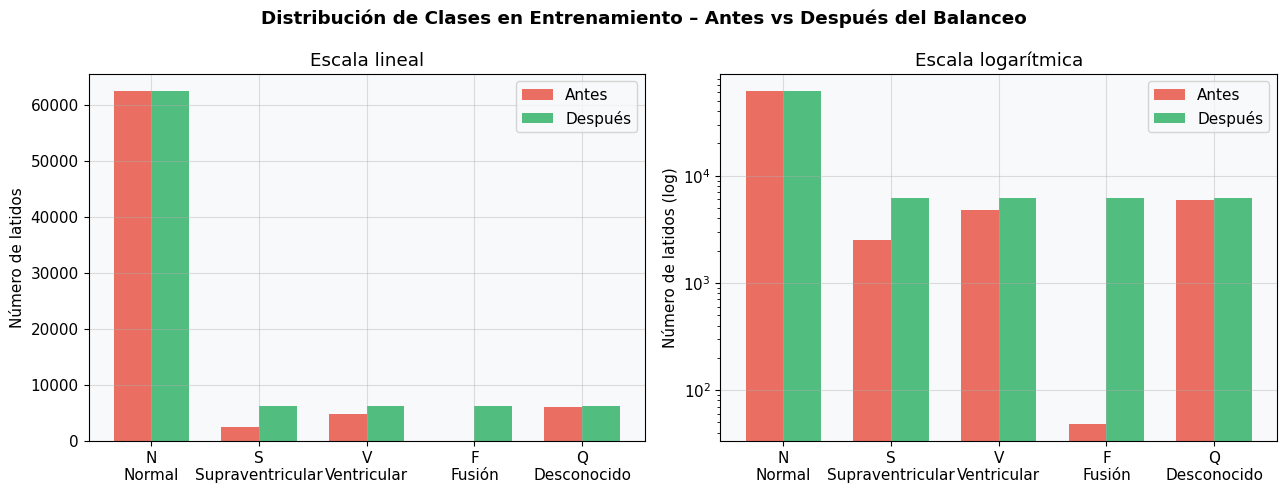

In [22]:
# ─────────────────────────────────────────────────────────
#  VISUALIZACIÓN DEL BALANCEO
# ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución de Clases en Entrenamiento – Antes vs Después del Balanceo',
             fontweight='bold')

x_pos = np.arange(len(classes_present))
width = 0.35
before_vals = [before.get(c, 0) for c in classes_present]
after_vals  = [after.get(c, 0)  for c in classes_present]

ax1.bar(x_pos - width/2, before_vals, width, label='Antes', color='#e74c3c', alpha=0.8)
ax1.bar(x_pos + width/2, after_vals,  width, label='Después', color='#27ae60', alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f"{c}\n{class_desc[c]}" for c in classes_present])
ax1.set_ylabel('Número de latidos')
ax1.set_title('Escala lineal')
ax1.legend()

ax2.bar(x_pos - width/2, before_vals, width, label='Antes', color='#e74c3c', alpha=0.8)
ax2.bar(x_pos + width/2, after_vals,  width, label='Después', color='#27ae60', alpha=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"{c}\n{class_desc[c]}" for c in classes_present])
ax2.set_ylabel('Número de latidos (log)')
ax2.set_title('Escala logarítmica')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.savefig('balanceo_clases.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Resumen Final del Pipeline

In [23]:
# ─────────────────────────────────────────────────────────
#  RESUMEN EJECUTIVO DEL PIPELINE
# ─────────────────────────────────────────────────────────
print("=" * 65)
print("           RESUMEN FINAL DEL PIPELINE DE DATOS")
print("           Avance 2 – Proyecto TCN-CVAE ECG")
print("=" * 65)

print("\n📁 DATASET")
print(f"   Nombre   : MIT-BIH Arrhythmia Database")
print(f"   Fuente   : PhysioNet (Kaggle: mondejar/mitbih-database)")
print(f"   Registros: {len(record_ids)} pacientes")
print(f"   Señal    : ECG 1D (Lead MLII), 360 Hz, ~30 min/paciente")
print(f"   Formato  : .dat (señal), .hea (header), .atr (anotaciones)")

print("\n🔧 PREPROCESAMIENTO")
print(f"   1. Filtro pasa-alto  : Butterworth 4°, 0.5 Hz  (elimina baseline wander)")
print(f"   2. Filtro Notch      : IIR 60 Hz, Q=30         (elimina ruido red eléctrica)")
print(f"   3. Filtro pasa-bajo  : Butterworth 4°, 45 Hz   (elimina EMG muscular)")
print(f"   4. Segmentación      : Ventana de {WINDOW_SIZE} muestras centrada en pico R")
print(f"                         ({WINDOW_SIZE/FS*1000:.0f} ms de duración)")
print(f"   5. Normalización     : Min-Max [0,1] por latido individual")
print(f"   6. Mapeo AAMI        : {len(AAMI_MAP)} símbolos → 5 clases")

print("\n📊 ESTADÍSTICAS DE LOS DATOS")
print(f"   Total latidos válidos: {len(X):,}")
print(f"   Shape tensor         : {X.shape} (float32)")
print(f"   Memoria              : {X.nbytes/1e6:.1f} MB")

print("\n🔀 DIVISIÓN DEL DATASET")
print(f"   Estrategia: Patient-Level Split (anti-contaminación)")
print(f"   Train      : {len(X_train):>8,} latidos  ({len(X_train)/len(X)*100:.1f}%) – {len(train_patients)} pacientes")
print(f"   Validation : {len(X_val):>8,} latidos  ({len(X_val)/len(X)*100:.1f}%) – {len(val_patients)} pacientes")
print(f"   Test       : {len(X_test):>8,} latidos  ({len(X_test)/len(X)*100:.1f}%) – {len(test_patients)} pacientes")

print("\n⚖️  MANEJO DE DESBALANCE")
print(f"   Técnica: Oversampling aleatorio de clases minoritarias")
print(f"   Aplicado: Solo en entrenamiento")
print(f"   Train balanceado: {len(X_train_bal):,} latidos")

print("\n📦 LISTO PARA FASE 3: Arquitectura TCN-CVAE")
print("   X_train_bal → Encoder TCN → z (latente) → Decoder TCN → señal sintética")
print("=" * 65)

           RESUMEN FINAL DEL PIPELINE DE DATOS
           Avance 2 – Proyecto TCN-CVAE ECG

📁 DATASET
   Nombre   : MIT-BIH Arrhythmia Database
   Fuente   : PhysioNet (Kaggle: mondejar/mitbih-database)
   Registros: 48 pacientes
   Señal    : ECG 1D (Lead MLII), 360 Hz, ~30 min/paciente
   Formato  : .dat (señal), .hea (header), .atr (anotaciones)

🔧 PREPROCESAMIENTO
   1. Filtro pasa-alto  : Butterworth 4°, 0.5 Hz  (elimina baseline wander)
   2. Filtro Notch      : IIR 60 Hz, Q=30         (elimina ruido red eléctrica)
   3. Filtro pasa-bajo  : Butterworth 4°, 45 Hz   (elimina EMG muscular)
   4. Segmentación      : Ventana de 256 muestras centrada en pico R
                         (711 ms de duración)
   5. Normalización     : Min-Max [0,1] por latido individual
   6. Mapeo AAMI        : 16 símbolos → 5 clases

📊 ESTADÍSTICAS DE LOS DATOS
   Total latidos válidos: 109,451
   Shape tensor         : (109451, 256) (float32)
   Memoria              : 112.1 MB

🔀 DIVISIÓN DEL DATASET
  

In [24]:
# ─────────────────────────────────────────────────────────
#  GUARDAR LOS ARRAYS PROCESADOS EN DISCO  (opcional)
#  Útil para no tener que volver a correr el preprocesamiento
# ─────────────────────────────────────────────────────────
import os
save_dir = '/content/ecg_processed'
os.makedirs(save_dir, exist_ok=True)

np.save(f'{save_dir}/X_train.npy',     X_train_bal)
np.save(f'{save_dir}/y_train.npy',     y_train_bal)
np.save(f'{save_dir}/X_val.npy',       X_val)
np.save(f'{save_dir}/y_val.npy',       y_val)
np.save(f'{save_dir}/X_test.npy',      X_test)
np.save(f'{save_dir}/y_test.npy',      y_test)

# También guardar el metadata con Polars
meta_df.write_parquet(f'{save_dir}/metadata.parquet')

print("✅ Arrays guardados en", save_dir)
for f in os.listdir(save_dir):
    fpath = os.path.join(save_dir, f)
    print(f"   {f:<30} {os.path.getsize(fpath)/1e6:.1f} MB")

print("\n💡 Para cargarlos en el siguiente notebook:")
print("   X_train = np.load('/content/ecg_processed/X_train.npy')")
print("   y_train = np.load('/content/ecg_processed/y_train.npy')")

✅ Arrays guardados en /content/ecg_processed
   y_test.npy                     0.1 MB
   X_test.npy                     17.4 MB
   y_train.npy                    0.3 MB
   X_train.npy                    89.4 MB
   X_val.npy                      17.1 MB
   metadata.parquet               0.2 MB
   y_val.npy                      0.1 MB

💡 Para cargarlos en el siguiente notebook:
   X_train = np.load('/content/ecg_processed/X_train.npy')
   y_train = np.load('/content/ecg_processed/y_train.npy')


---
## ✅ Fin del Avance 2

**Lo que queda para el Avance 3:** Implementación de la arquitectura TCN-CVAE (Fases 3 y 4 del plan de implementación):
- Módulo Encoder TCN
- Módulo de Reparametrización
- Módulo Decoder TCN con upsampling
- Función de pérdida MSE + KL con β-scheduling
- Generación de latidos sintéticos condicionales